# 双向循环神经网络

## 隐马尔科夫模型的动态规划

### 马尔科夫模型简介
在处理时间序列的时候， 为了预测当前时间步$x_t$，需要参考过去发生的所有过去的事情 $x_1, \dots, x_{t-1}$，但是在马尔科夫条件下，不用考虑过去所有的信息：
* 只要我们能用一个较短的近期历史 $x_{t-\tau}, \dots, x_{t-1}$ 来近似代替所有的历史 $x_1, \dots, x_{t-1}$，并且预测结果依然足够精确，我们就说这个序列满足马尔可夫条件。
#### 一阶马尔科夫模型
即$ tau = 1$ ,即序列中每一个状态的发生，仅仅依赖于它紧挨着的前一个状态，与更早的历史完全无关
$$P(x_1, \dots, x_T) = \prod_{t=1}^T P(x_t \mid x_{t-1})$$

### 隐马尔科夫模型
基础的马尔科夫模型存在问题，如果考虑长远的上下文，需要存储的词的组合数量会随着词表的大小指数级增加；
为了解决上述的问题，引入隐状态参与模型的计算：$P(x_t \mid x_{t-1}, \dots, x_1) \approx P(x_t \mid h_{t-1})$。

假设我们有一句话，中间空了一个词 $x_j$，我们需要根据它前面和后面的所有词 $x_{-j} = (x_1, \dots, x_{j-1}, x_{j+1}, \dots, x_T)$ 来填空，即求 $P(x_j \mid x_{-j})$

为了解决这个问题，我们建立一个隐马尔可夫模型。在这个模型中，每个观测到的词 $x_t$ 都由一个隐藏状态 $h_t$ 控制，且隐藏状态之间有随时间转移的概率。

建立联合概率分布为：
$$P(x_1, \dots, x_T, h_1, \dots, h_T) = \prod_{t=1}^T P(h_t \mid h_{t-1})P(x_t \mid h_t), \text{ 其中 } P(h_1 \mid h_0) = P(h_1)$$

这个是由两部分的连乘组合的：
* 状态转移概率：假设隐状态满足一阶马尔科夫条件，即$P(h_t \mid h_{t-1})$ 
* 发射概率（根据当前状态生成特定词的概率）：$P(x_t \mid h_t)$

这里主要面临的问题是：计算$P(x_j \mid x_{-j}), x_{-j} = (x_1, \dots, x_{j-1}, x_{j+1}, \dots, x_T)$时， 因为这个概率表达式中没有隐变量，所以考虑要对$h_1, \dots, h_T$ 进行穷举求和

下面使用DP算法

#### DP算法

##### 前向递归
把时间步t之前的所有历史信息打包压缩起来，根据联合概率密度分布函数可以得到（这个求和的意思是对所有可能的隐状态组合进行求和）：
$$P(x_1, \dots, x_T) = \sum_{h_1, \dots, h_T} P(x_1, \dots, x_T, h_1, \dots, h_T)$$

上式等于：
$$= \sum_{h_1, \dots, h_T} \prod_{t=1}^T P(h_t \mid h_{t-1}) P(x_t \mid h_t)$$

上式等于：
$$= \sum_{h_2, \dots, h_T} \underbrace{\left[ \sum_{h_1} P(h_1) P(x_1 \mid h_1) P(h_2 \mid h_1) \right]}_{\pi_2(h_2)} P(x_2 \mid h_2) \prod_{t=3}^T P(h_t \mid h_{t-1}) P(x_t \mid h_t)$$

这样做是因为：跟 $h_1$ 相关的项只有三个：初始概率 $P(h_1)$、发射概率 $P(x_1 \mid h_1)$ 和转移概率 $P(h_2 \mid h_1)$。后面的项（从 $t=3$ 开始）根本不包含 $h_1$。  

上式等于：
$$= \sum_{h_3, \dots, h_T} \underbrace{\left[ \sum_{h_2} \pi_2(h_2) P(x_2 \mid h_2) P(h_3 \mid h_2) \right]}_{\pi_3(h_3)} P(x_3 \mid h_3) \prod_{t=4}^T P(h_t \mid h_{t-1}) P(x_t \mid h_t)$$

最终化简为：
$$= \sum_{h_T} \pi_T(h_T) P(x_T \mid h_T)$$

前向递归可以写成：
$$
\pi_{t+1}(h_{t+1}) = \sum_{h_t} \pi_t(h_t) P(h_{t+1} \mid h_t) P(x_{t+1} \mid h_{t+1})
$$

递归的初始化条件被定义为：$\pi_1(h_1) = P(h_1)$

##### 后向递归
根据完整的联合概率：
$$P(x_1, \dots, x_T) = \sum_{h_1, \dots, h_T} P(x_1, \dots, x_T, h_1, \dots, h_T)$$
$$= \sum_{h_1, \dots, h_T} \prod_{t=1}^{T-1} P(h_t \mid h_{t-1}) P(x_t \mid h_t) \cdot P(h_T \mid h_{T-1}) P(x_T \mid h_T)$$


从尾部开始提取公因式：把所有包含 $h_T$ 的项放进方括号，先局部对 $h_T$ 进行求和：

上式等于：
$$= \sum_{h_1, \dots, h_{T-1}} \prod_{t=1}^{T-1} P(h_t \mid h_{t-1}) P(x_t \mid h_t) \cdot \underbrace{\left[ \sum_{h_T} P(h_T \mid h_{T-1}) P(x_T \mid h_T) \right]}_{\rho_{T-1}(h_{T-1})}$$

一直这样递归就可以得到：
$$= \sum_{h_1, \dots, h_{T-2}} \prod_{t=1}^{T-2} P(h_t \mid h_{t-1}) P(x_t \mid h_t) \cdot \underbrace{\left[ \sum_{h_{T-1}} P(h_{T-1} \mid h_{T-2}) P(x_{T-1} \mid h_{T-1}) \rho_{T-1}(h_{T-1}) \right]}_{\rho_{T-2}(h_{T-2})}$$

原式可以被表达为：
$$= \sum_{h_1} P(h_1) P(x_1 \mid h_1) \rho_1(h_1)$$

后向递归可以被写成：
$\rho_{t-1}(h_{t-1}) = \sum_{h_t} P(h_t \mid h_{t-1}) P(x_t \mid h_t) \rho_t(h_t)$。

## 双向模型

书上介绍的是具有单个隐藏层的的双向循环神经网络的架构

* 前向隐状态：$\overrightarrow{H}_t = \phi(X_t W_{xh}^{(f)} + \overrightarrow{H}_{t-1} W_{hh}^{(f)} + b_h^{(f)})$
* 反向隐状态：$\overleftarrow{H}_t = \phi(X_t W_{xh}^{(b)} + \overleftarrow{H}_{t+1} W_{hh}^{(b)} + b_h^{(b)})$

输入$X_t$会同时喂给两个方向的网络：
* 前向隐状态 $\overrightarrow{H}_t$ 依赖于上一个时间步 $\overrightarrow{H}_{t-1}$，负责收集并浓缩时间步 $t$ 之前的历史信息。
* 反向隐状态 $\overleftarrow{H}_t$ 依赖于下一个时间步 $\overleftarrow{H}_{t+1}$，负责收集并浓缩时间步 $t$ 之后的未来信息。  

输出层的计算：模型会将当前时间步的$\overrightarrow{H}_t$和反向隐状态$\overleftarrow{H}_t$拼接起来($H_t \in \mathbb{R}^{n \times 2n}$)，作为输入，通过全连接层计算输出$O_t$。
$$O_t = H_t W_{hq} + b_q$$

### 局限性
双向RNN无法预测未来：
* 训练阶段：在训练的时候，手里有完整的句子
* 测试阶段：预测的时候，我们不知道下一个token，导致反向RNN无法接受到未来的输入，而模型在训练的时候已经严重依赖未来的信息，现在抽取未来的信息，预测精度会变差

这里反映在代码上就是8.5小节的预测代码中:
```
def predict_ch8(prefix, num_preds, net, vocab, device):  # 依次是：当前已经预测的token列表，需要生成的token数量，定义的网络对象，map对象，GPU
    """在prefix后面生成新字符"""
    state = net.begin_state(batch_size=1, device=device)  # 初始的隐藏状态，表示对一个字符做预测
    outputs = [vocab[prefix[0]]]  # 第一个token的下标，放到output列表中
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1)) # get_input函数存下最近预测的词作为当前时刻的输入
    for y in prefix[1:]:  # 预热期
        _, state = net(get_input(), state) # 更新已知序列的隐藏状态，不care输出，这里一直更新到当前时间步的隐藏状态,这里调用的net相当于是前向传播一步
        outputs.append(vocab[y])  # 把当前token的下标也放到output列表中
    for _ in range(num_preds):  # 预测num_preds步
        y, state = net(get_input(), state) # y是one-hot编码之后的向量，其shape是(1, vocab_size)
        outputs.append(int(y.argmax(dim=1).reshape(1))) # 取y中概率最大的那个，作为当前预测的token的下标
    return ''.join([vocab.idx_to_token[i] for i in outputs]) # 使用空字符join起来并进行输出
```
其中get_input函数是存下最近预测的词作为当前时刻的输入，传给模型的net(get_input(), state)的是一个长度为1的单字符张量

### 代码测试

这里给一个错误的应用

perplexity 1.1, 88980.2 tokens/sec on cuda:0
time travellerererererererererererererererererererererererererer
travellerererererererererererererererererererererererererer


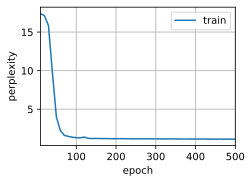

In [2]:
import torch
from torch import nn
from d2l import torch as d2l

# 加载数据
batch_size, num_steps, device = 32, 35, d2l.try_gpu()
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)
# 通过设置“bidirective=True”来定义双向LSTM模型
vocab_size, num_hiddens, num_layers = len(vocab), 256, 2
num_inputs = vocab_size
lstm_layer = nn.LSTM(num_inputs, num_hiddens, num_layers, bidirectional=True)
model = d2l.RNNModel(lstm_layer, len(vocab))
model = model.to(device)
# 训练模型
num_epochs, lr = 500, 1
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)